# Customer Churn – Exploratory Data Analysis (EDA)

## Business Objective
Understand customer behavior and identify key factors associated with churn, enabling proactive retention strategies.

## Key Questions
- What is the churn rate?
- Which customer segments churn the most?
- How do tenure, contract type, and charges relate to churn?


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/telco_churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Load Dataset

In [4]:
DATA_PATH = "../data/raw/telco_churn.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Basic Dataset Overview


In [6]:
df.info()  
df.describe(include='all')
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Target Variable Analysis

In [7]:
churn_counts = df["Churn"].value_counts()
churn_percent = churn_counts / len(df) * 100

pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_percent.round(2)
})


,Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


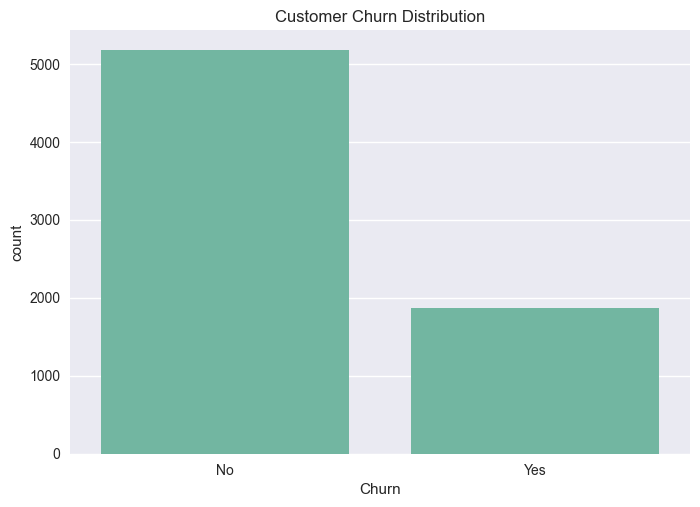

In [8]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()


- The dataset is imbalanced.
- Churn customers represent a smaller but critical segment.
- Recall will be more important than accuracy.


Demographic Features vs Churn
Gender vs Churn

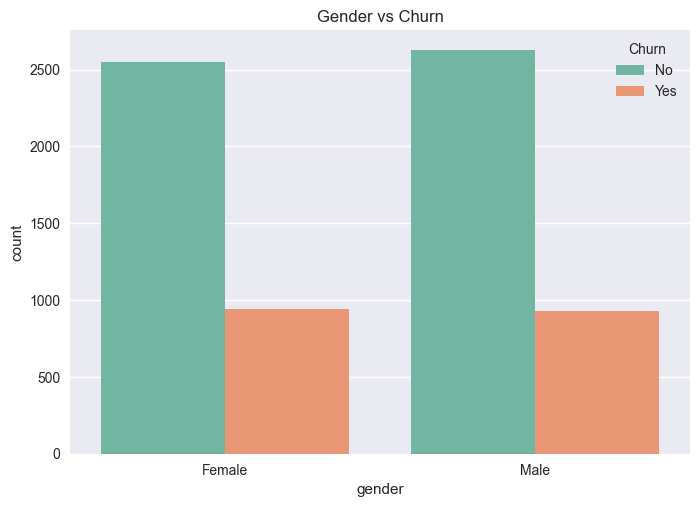

In [9]:
sns.countplot(data=df, x="gender", hue="Churn")
plt.title("Gender vs Churn")
plt.show()


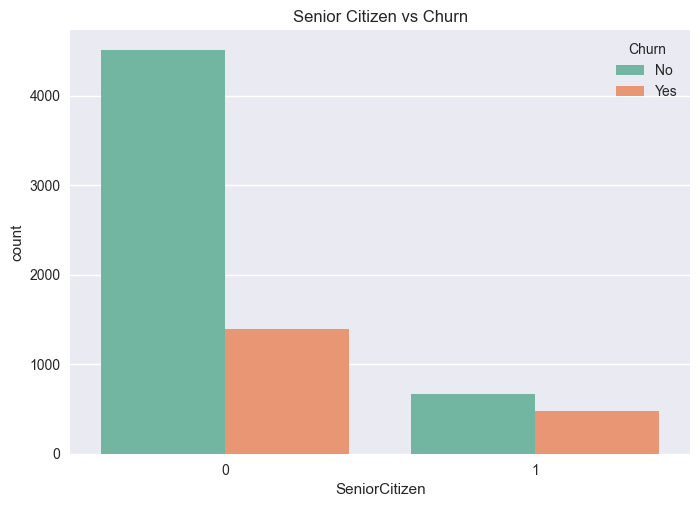

In [10]:
#Senior Citizen
sns.countplot(data=df, x="SeniorCitizen", hue="Churn")
plt.title("Senior Citizen vs Churn")
plt.show()


Contract & Service Features

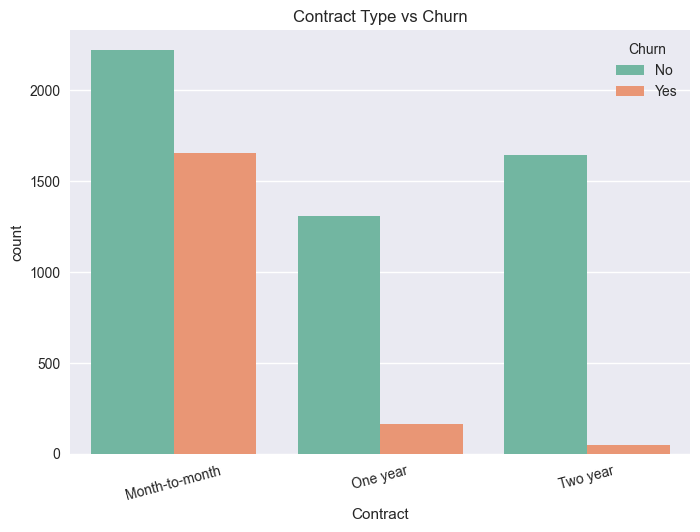

In [12]:
#Contract Type
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()


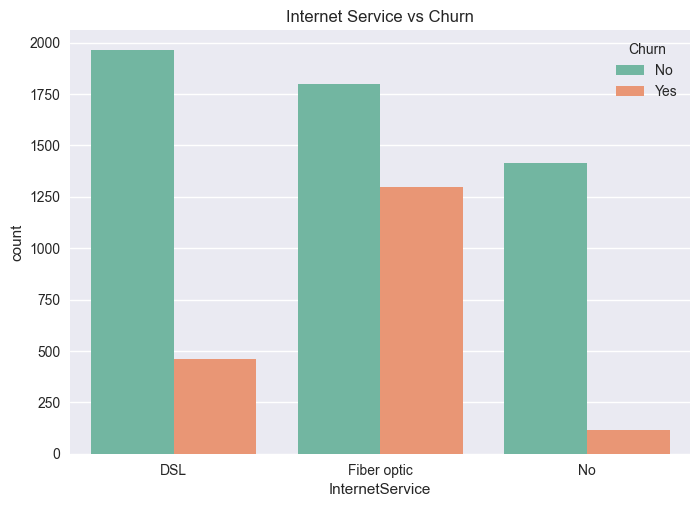

In [13]:
#Internet Service
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Internet Service vs Churn")
plt.show()


📌 Business insight:
- Month-to-month customers churn significantly more
- Long-term contracts reduce churn risk


Charges & Tenure Analysis

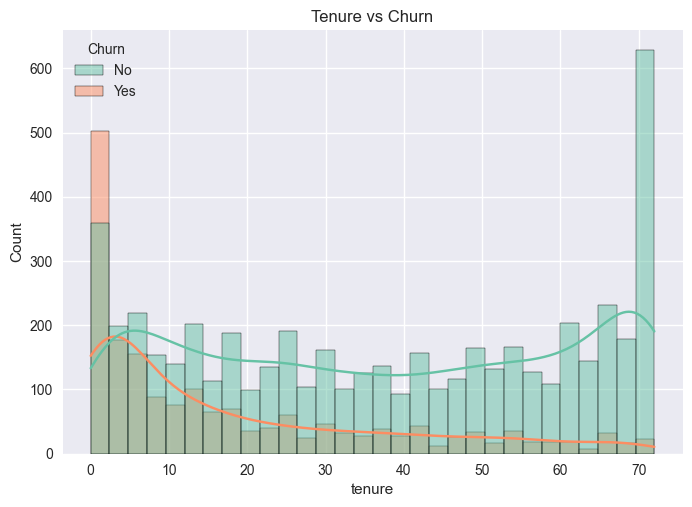

In [14]:
#Tenure Distribution
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)
plt.title("Tenure vs Churn")
plt.show()


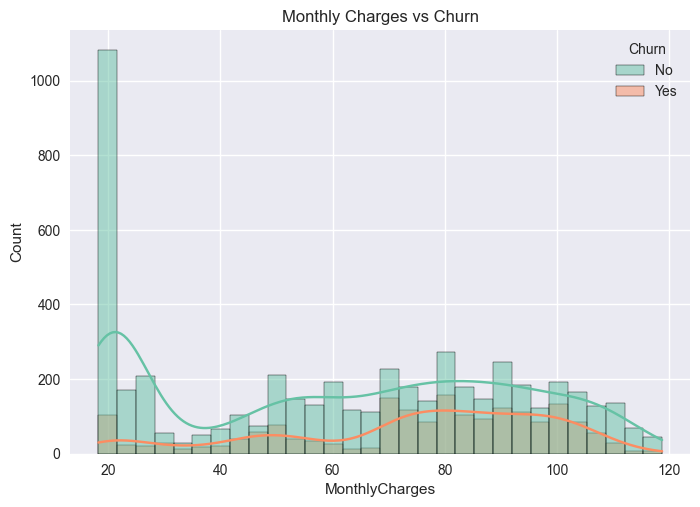

In [15]:
#Monthly Charges
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30, kde=True)
plt.title("Monthly Charges vs Churn")
plt.show()


📌 Key insight:
- New customers churn more
- High monthly charges increase churn probability


Correlation (Numerical Only)

In [16]:
#Convert TotalCharges safely
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


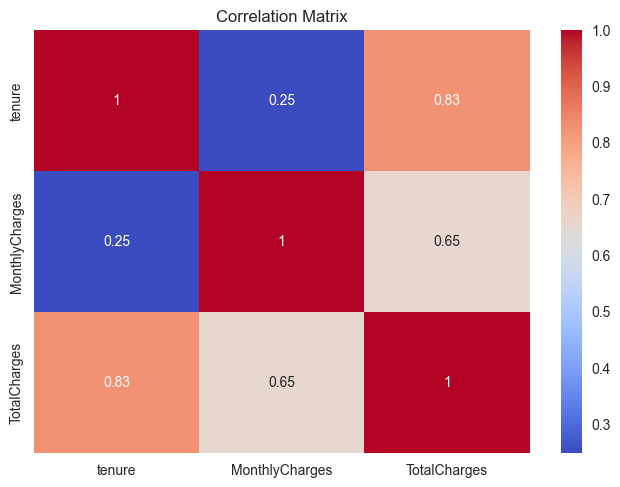

In [17]:
corr = df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


EDA Summary

## Key Findings
- Churn is highly associated with:
  - Month-to-month contracts
  - Short tenure
  - Higher monthly charges
- Demographics play a smaller role
- Strong class imbalance → recall-focused modeling
